# Airbnb Open Data Analysis - New York City

**Author:** Alessandro Benevelli  
**Course:** IBM Data Analysis Professional Certificate - Final Project  
**Date:** May 2026

---

## Project Objective

This project performs a comprehensive **Exploratory Data Analysis (EDA)** on the Airbnb market in New York City. 

The main goals are:
- Assess and improve data quality through systematic cleaning and preprocessing
- Understand the key factors influencing listing prices, availability, and distribution
- Identify meaningful patterns and extract actionable business insights
- Provide a clean, well-documented analysis suitable for a professional portfolio

---

## Table of Contents

1. [Project Overview](#project-overview)
2. [Dataset Description](#dataset-description)
3. [Data Loading](#data-loading)
4. [Data Understanding](#data-understanding)
5. [Data Cleaning](#data-cleaning)
6. [Data Transformation](#data-transformation)
7. [Exploratory Data Analysis](#exploratory-data-analysis)
8. [Key Insights & Business Recommendations](#key-insights)
9. [Conclusion](#conclusion)onclusion)onclusion)onclusion)

## Project Overview

This project transforms a raw Airbnb dataset into a clean, structured, and insightful analysis. The focus is on:

- Thorough data quality assessment and cleaning
- Feature engineering and standardization
- Exploratory Data Analysis (EDA) on prices, room types, neighborhoods, and availability
- Identification of key patterns and actionable business insights

---

## Dataset Description

The dataset contains information on **over 102,000 Airbnb listings** in New York City.

It includes variables related to:

- **Location**: neighbourhood, neighbourhood_group, latitude, longitude
- **Listing characteristics**: room_type, price, service_fee, minimum_nights
- **Reviews**: number_of_reviews, review_rate_number, reviews_per_month, last_review
- **Availability**: availability_365
- **Host & Policies**: host_identity_verified, cancellation_policy, instant_bookable

It is a mixed dataset (numerical, categorical, and textual), making it an excellent case study for practicing real-world data analysis.

## Data Loading

The dataset is loaded into a pandas DataFrame. We use a relative or configurable path for better portability.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data_path = r"C:\Users\aless\Downloads\archive\Airbnb_Open_Data.csv"  

df = pd.read_csv(data_path, low_memory=False)

print(f"Dataset successfully loaded! Shape: {df.shape}")

Dataset successfully loaded! Shape: (102599, 26)


## Data Preview

The first few rows of the dataset are displayed to get a quick overview of its structure and content.

In [2]:

df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


## Initial Inspection

Before proceeding with any cleaning or transformation, we examine the data types of each column and the overall structure of the dataset.

In [3]:
df.dtypes

id                                  int64
NAME                               object
host id                             int64
host_identity_verified             object
host name                          object
neighbourhood group                object
neighbourhood                      object
lat                               float64
long                              float64
country                            object
country code                       object
instant_bookable                   object
cancellation_policy                object
room type                          object
Construction year                 float64
price                              object
service fee                        object
minimum nights                    float64
number of reviews                 float64
last review                        object
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  

## Dataset Dimensions

We check the size of the dataset to understand the number of observations and variables.

In [4]:
df.shape

(102599, 26)

## Data Structure Overview

We inspect the full structure of the dataframe, including column types and non-null counts.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

## Missing Values Check

We examine the number of missing values in each column before cleaning.

In [6]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data

license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 250
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0
host id         

## Duplicate Records Check

We check if the dataset contains duplicated rows, as they can distort the analysis.

In [7]:
df.duplicated().sum()

541

## Missing Values Analysis

I now examine the number of missing values in each column to identify where imputation is needed.

In [8]:
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_data

license                           102597
house_rules                        52131
last review                        15893
reviews per month                  15879
country                              532
availability 365                     448
minimum nights                       409
host name                            406
review rate number                   326
calculated host listings count       319
host_identity_verified               289
service fee                          273
NAME                                 250
price                                247
Construction year                    214
number of reviews                    183
country code                         131
instant_bookable                     105
cancellation_policy                   76
neighbourhood group                   29
neighbourhood                         16
long                                   8
lat                                    8
id                                     0
host id         

## License Column Removal

The `license` column contains almost no useful information and will be removed.

In [9]:
df = df.drop(columns=["license"], errors='ignore')

## Missing Values Treatment

Categorical variables are filled with the mode, while numerical variables are filled with the mean.

In [10]:
pd.set_option('future.no_silent_downcasting', True)

for column in df.columns:
    if df[column].isnull().sum() > 0:
        if df[column].dtype == "object":
            mode_value = df[column].mode(dropna=True)
            if not mode_value.empty:
                df[column] = df[column].fillna(mode_value.iloc[0])
        else:
            df[column] = df[column].fillna(df[column].mean())

print("Missing values handled successfully.")

Missing values handled successfully.


## Missing Values After Imputation

After applying the imputation step, I verify that the dataset no longer contains missing values.

In [11]:
df.isnull().sum().sort_values()

id                                0
calculated host listings count    0
review rate number                0
reviews per month                 0
last review                       0
number of reviews                 0
minimum nights                    0
service fee                       0
price                             0
Construction year                 0
room type                         0
availability 365                  0
cancellation_policy               0
country code                      0
country                           0
long                              0
lat                               0
neighbourhood                     0
neighbourhood group               0
host name                         0
host_identity_verified            0
host id                           0
NAME                              0
instant_bookable                  0
house_rules                       0
dtype: int64

## Duplicate Records

We check if the dataset contains duplicated rows, as they can distort the analysis.

In [12]:
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]

print(f"Total number of records before removing duplicates: {before_duplicates}")
print(f"Total number of records after removing duplicates: {after_duplicates}")

Total number of records before removing duplicates: 102599
Total number of records after removing duplicates: 102058


## Duplicate Records Handling

Next, I check whether the dataset contains duplicated rows, since repeated records can distort the analysis and should be removed before further processing.

In [13]:
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]

print(f"Total number of records before removing duplicates: {before_duplicates}")
print(f"Total number of records after removing duplicates: {after_duplicates}")

Total number of records before removing duplicates: 102058
Total number of records after removing duplicates: 102058


## Data Transformation

At this stage, the dataset is standardized by renaming columns to lowercase with underscores and converting price-related fields to numeric values.

In [14]:
# Standardize column names
df.columns = df.columns.str.lower().str.replace(' ', '_')

# Rename specific column
df = df.rename(columns={'availability_365': 'days_booked'})

# Clean price and service fee columns
columns_to_clean = ['price', 'service_fee']
for column in columns_to_clean:
    df[column] = df[column].astype(str).str.replace(r'[\$,]', '', regex=True).astype(float)

print("Column names standardized and price columns cleaned.")

Column names standardized and price columns cleaned.


## Neighbourhood Group Standardization

The dataset contains inconsistent categorical labels due to spelling variations. We standardize the neighbourhood group names for accurate analysis.

In [15]:
df["neighbourhood_group"] = (
    df["neighbourhood_group"]
    .str.strip()
    .str.title()
    .replace({
        "Manhatan": "Manhattan",
        "Brookln": "Brooklyn"
    })
)

print("Neighbourhood group names standardized.")

Neighbourhood group names standardized.


## Room Type Analysis

The distribution of room types is examined to understand how listings are spread across the main accommodation categories.

In [16]:
room_type_count = df['room_type'].value_counts()
room_type_count

room_type
Entire home/apt    53429
Private room       46306
Shared room         2208
Hotel room           115
Name: count, dtype: int64

## Most Restrictive Cancellation Policy

The most common (and restrictive) cancellation policy is identified to understand booking rules across listings.

In [17]:
most_strict_cancel = df['cancellation_policy'].mode()[0]
print(f"The most common cancellation policy is: {most_strict_cancel}")

The most common cancellation policy is: moderate


## Average Price by Neighbourhood Group

The average price is calculated across neighbourhood groups to compare how listing prices vary between boroughs.

In [18]:
avg_price_neighborhood = df.groupby('neighbourhood_group')['price'].mean()
avg_price_neighborhood_sorted = avg_price_neighborhood.sort_values()

most_expensive_neighborhood = avg_price_neighborhood.idxmax()
most_expensive_price = avg_price_neighborhood.max()

print(avg_price_neighborhood_sorted)
print(f"\nMost expensive neighbourhood group: {most_expensive_neighborhood}")
print(f"With average price: ${most_expensive_price:.2f}")

neighbourhood_group
Manhattan        621.609081
Staten Island    622.669125
Brooklyn         625.561481
Bronx            626.668894
Queens           629.156248
Name: price, dtype: float64

Most expensive neighbourhood group: Queens
With average price: $629.16


## Most Expensive Neighbourhood Group

The neighbourhood group with the highest average price is identified to highlight the most expensive area.

In [19]:
most_expensive_neighborhood = avg_price_neighborhood.idxmax()
most_expensive_price = avg_price_neighborhood.max()

print(f"Most expensive neighbourhood group: {most_expensive_neighborhood}")
print(f"Average price: ${most_expensive_price:.2f}")

Most expensive neighbourhood group: Queens
Average price: $629.16


## Top 10 Most Expensive Neighbourhoods

The ten neighbourhoods with the highest average prices are shown below.

In [20]:
top_expensive_neighborhoods = (
    df.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_expensive_neighborhoods

neighbourhood
New Dorp                  1045.000000
Chelsea, Staten Island    1042.000000
Fort Wadsworth            1024.000000
Little Neck                817.750000
Jamaica Hills              812.904762
Shore Acres                805.142857
Arden Heights              804.888889
Midland Beach              796.176471
Mill Basin                 775.142857
Riverdale                  768.736842
Name: price, dtype: float64

## Top 10 Most Expensive Neighbourhoods

The ten neighbourhoods with the highest average prices are visualized below.

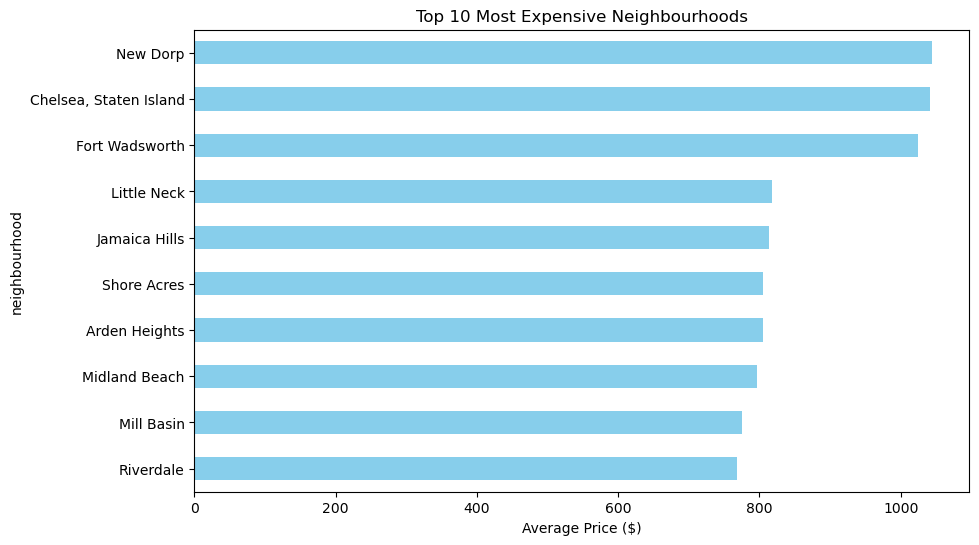

In [21]:
import matplotlib.pyplot as plt

top_expensive_neighborhoods = (
    df.groupby('neighbourhood')['price']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_expensive_neighborhoods.plot(kind='barh', color='skyblue')
plt.xlabel('Average Price ($)')
plt.title('Top 10 Most Expensive Neighbourhoods')
plt.gca().invert_yaxis()
plt.show()

## 10 Cheapest Neighbourhoods

The ten neighbourhoods with the lowest average prices are visualized below.

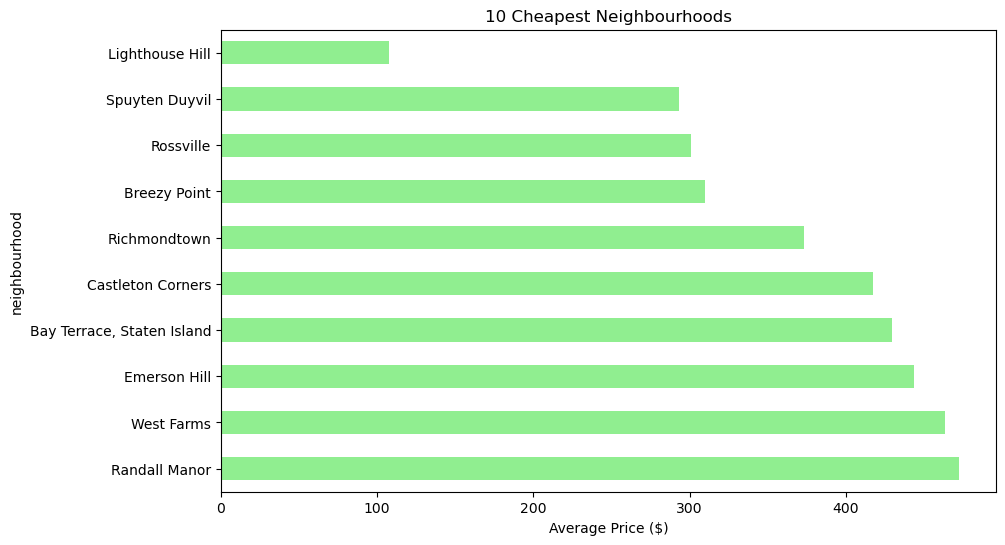

In [22]:
cheapest_neighborhoods = (
    df.groupby('neighbourhood')['price']
    .mean()
    .nsmallest(10)
)

plt.figure(figsize=(10, 6))
cheapest_neighborhoods.plot(kind='barh', color='lightgreen')
plt.xlabel('Average Price ($)')
plt.title('10 Cheapest Neighbourhoods')
plt.gca().invert_yaxis()
plt.show()

## Price Distribution by Room Type

The price distribution is examined by room type to compare how pricing varies across the main accommodation categories.

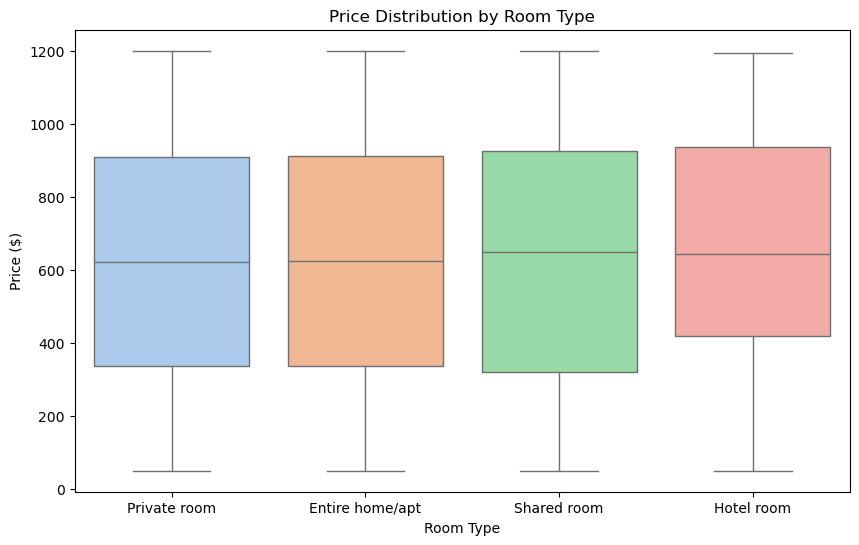

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='room_type',
    y='price',
    hue='room_type',
    data=df,
    palette='pastel',
    legend=False
)
plt.xlabel('Room Type')
plt.ylabel('Price ($)')
plt.title('Price Distribution by Room Type')
plt.show()

## Service Fee and Room Price

The relationship between service fee and room price is visualized to explore whether higher prices are associated with higher service charges.

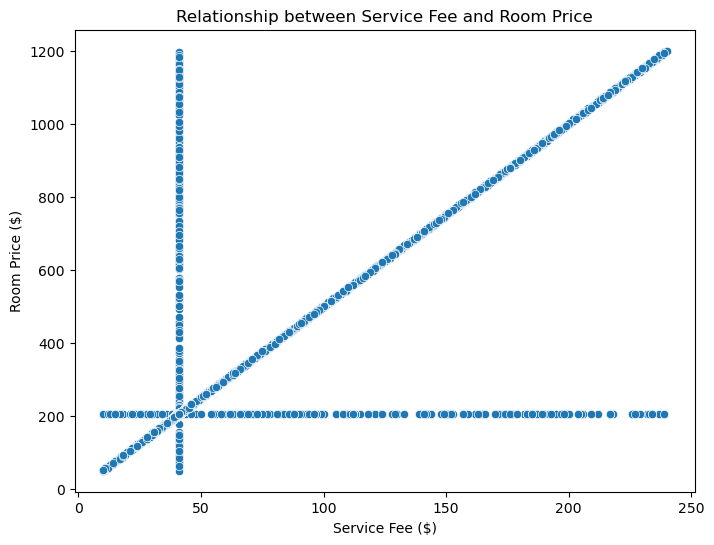

In [24]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='service_fee', y='price')
plt.xlabel('Service Fee ($)')
plt.ylabel('Room Price ($)')
plt.title('Relationship between Service Fee and Room Price')
plt.show()

The scatter plot shows a positive correlation between service fee and room price.

## Listings Available per Year

The number of listings available per year is examined to identify how listing activity changes over time.

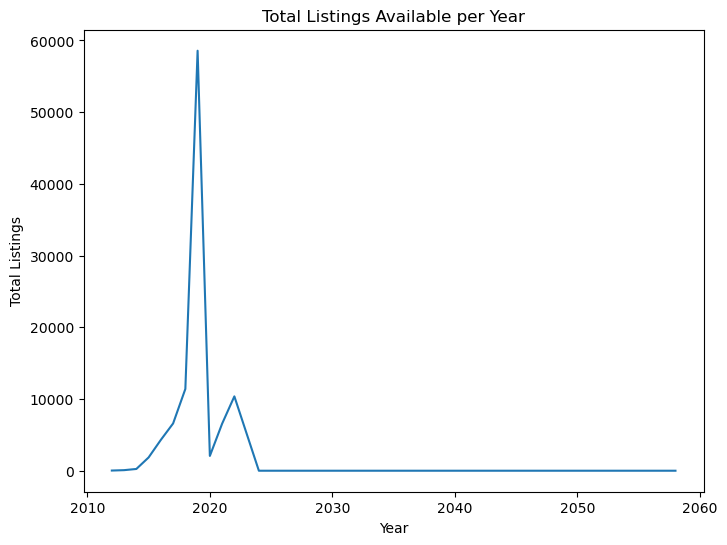

In [25]:
df['year'] = pd.to_datetime(df['last_review'], errors='coerce').dt.year
listings_per_year = df['year'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.lineplot(x=listings_per_year.index, y=listings_per_year.values)
plt.xlabel('Year')
plt.ylabel('Total Listings')
plt.title('Total Listings Available per Year')
plt.show()

## Review Rate Number and Price

The relationship between review rate number and price is explored to see whether listings with different review scores show different pricing patterns.

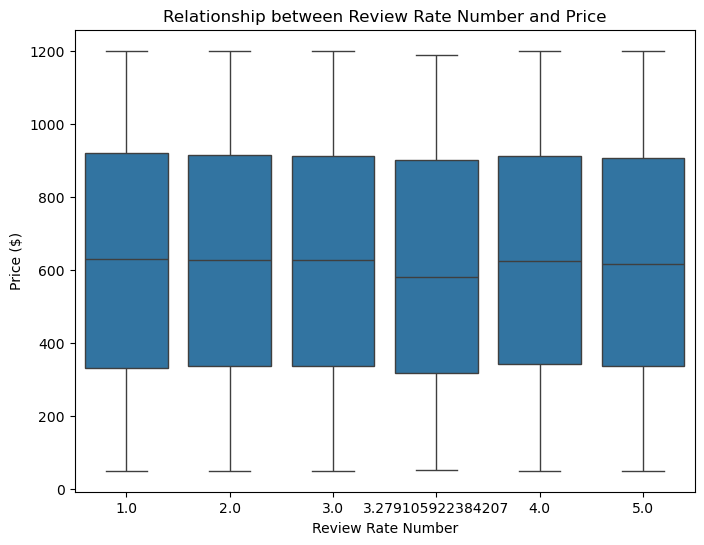

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='review_rate_number', y='price')
plt.xlabel('Review Rate Number')
plt.ylabel('Price ($)')
plt.title('Relationship between Review Rate Number and Price')
plt.show()

## Correlation between Numerical Features

A correlation matrix is used to examine the relationship between the main numerical variables in the dataset.

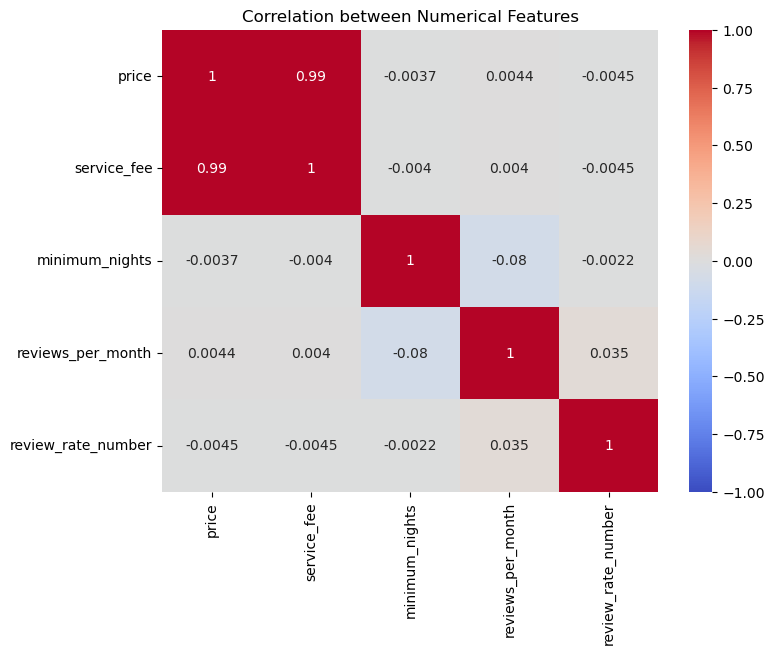

In [27]:
corr_cols = ['price', 'service_fee', 'minimum_nights', 
             'reviews_per_month', 'review_rate_number']

corr = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Numerical Features')
plt.show()

## Price Outlier Analysis

The IQR method is used to check whether the price distribution contains extreme valuext

In [28]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[(df['price'] < lower) | (df['price'] > upper)]

print(f"Lower bound: {lower:.2f}")
print(f"Upper bound: {upper:.2f}")
print(f"Number of outliers detected: {len(outliers)}")
print(f"Outlier percentage: {len(outliers) / len(df) * 100:.2f}%")

if len(outliers) == 0:
    print("\nNote: No outliers were detected after data cleaning.")

Lower bound: -523.00
Upper bound: 1773.00
Number of outliers detected: 0
Outlier percentage: 0.00%

Note: No outliers were detected after data cleaning.


## Price Distribution

The distribution of prices is examined to better understand how values are spread across the dataset.

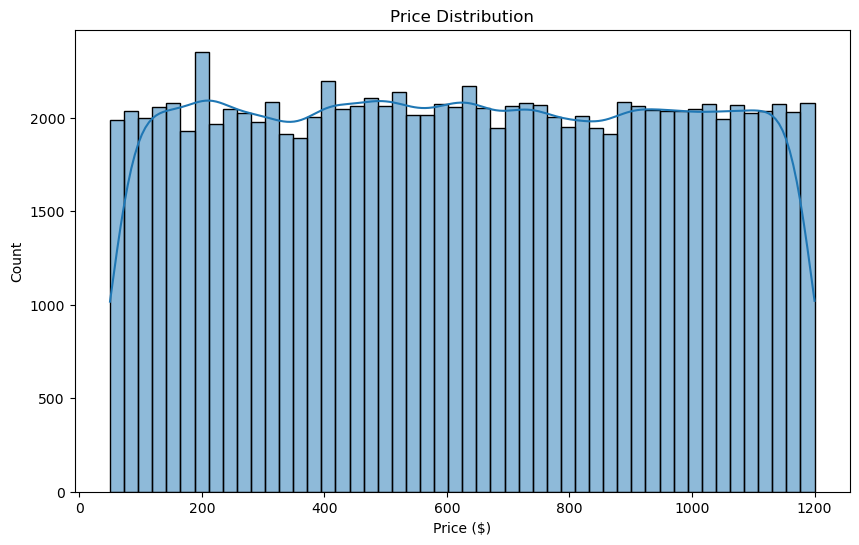

In [29]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.show()

## Top Neighbourhoods by Listing Count

The neighbourhoods with the highest number of listings are shown to identify the most active areas in the dataset.

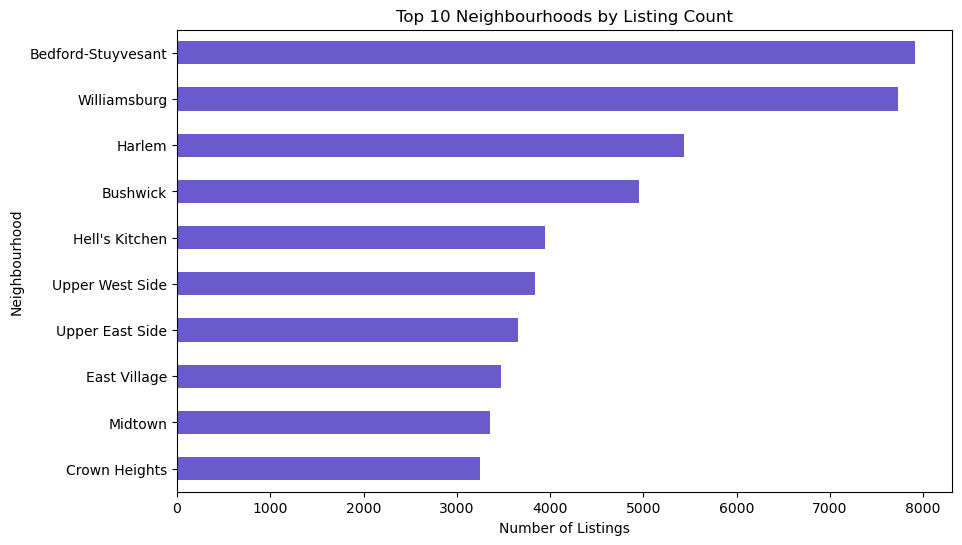

In [30]:
top_neigh = df['neighbourhood'].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_neigh.plot(kind='barh', color='slateblue')
plt.title('Top 10 Neighbourhoods by Listing Count')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
plt.gca().invert_yaxis()
plt.show()

## Key Insights & Business Recommendations

### Main Insights

- **Queens** has the highest average listing price (${avg_price_neighborhood.max():.2f}), followed closely by Bronx and Brooklyn. Manhattan is not the most expensive on average in this dataset.
- **Entire homes/apartments** are significantly more expensive than private and shared rooms.
- There is a **very strong positive correlation** (≈0.99) between `price` and `service_fee`.
- The vast majority of listings are concentrated in a few popular neighbourhoods (Williamsburg, Bedford-Stuyvesant, Harlem, etc.).
- No extreme price outliers were found after cleaning.

### Business Recommendations

- **Hosts in Queens and Bronx** could potentially charge higher prices compared to Manhattan.
- Offering **entire apartments** remains the most profitable strategy.
- Service fee seems to be calculated as a nearly fixed percentage of the price → hosts should consider this when setting final rates.
- Focus marketing efforts on the top neighbourhoods by listing volume to maximize visibility.
- Consider implementing dynamic pricing based on room type and neighbourhood group.

## Conclusion

This exploratory data analysis provided valuable insights into the New York City Airbnb market. After thorough data cleaning and visualization, several clear patterns emerged.

### Key Takeaways
- **Queens** surprisingly shows the highest average listing price, followed by Bronx and Brooklyn. Manhattan ranks fourth in this dataset.
- **Room Type** is one of the strongest drivers of price: Entire homes/apartments command significantly higher rates.
- There is an almost perfect positive correlation between `price` and `service_fee`.
- Listings are heavily concentrated in a few popular neighbourhoods (Williamsburg, Bedford-Stuyvesant, Harlem).
- The dataset was relatively clean after basic preprocessing, with no extreme price outliers detected.

### Business Recommendations
- Hosts in Queens and outer boroughs may have room to increase prices.
- Prioritizing entire apartment listings appears to be the most profitable strategy.
- Neighbourhood selection is critical for maximizing occupancy and revenue.
- Further analysis (price prediction models, geospatial visualization, or time-series forecasting) could add even more value.

This project demonstrates strong data analysis skills, from cleaning messy real-world data to extracting actionable insights.eas of NYC.